In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
sns.set_theme(style="whitegrid", palette="muted")


Raneem

In [ ]:
file_path = '/content/TEAM22_Master_Dataset.csv'
df = pd.read_csv(file_path)

display(df.head())

,Patient_ID,MCHC,Anti_tissue_transglutaminase,MCV,Progesterone_antibodies,Eosinophils,Anti_desmoglein_1,Weight loss,Anti_parietal_cell,C3,...,Dizziness,ACPA,Anti_BP230,Brittle hair or hair loss,C1_inhibitor,Anti_CBir1,DGP,EMA,anti_Scl_70,Gender
0,1,33.12,0.0,99.85,0.0,4.02,0.0,0.0,0.0,1.32,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Female
1,2,31.07,0.0,94.86,0.0,1.67,0.0,1.0,0.0,0.40,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,Male
2,3,35.61,0.0,88.26,0.0,4.32,0.0,0.0,0.0,0.95,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Male
3,4,33.93,0.0,85.95,0.0,3.12,0.0,1.0,0.0,1.06,...,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,Female
4,5,31.29,0.0,93.16,0.0,4.60,0.0,1.0,0.0,0.73,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Female


# Data Quality & Health Check

In [ ]:
df.head()


,Patient_ID,MCHC,Anti_tissue_transglutaminase,MCV,Progesterone_antibodies,Eosinophils,Anti_desmoglein_1,Weight loss,Anti_parietal_cell,C3,...,Dizziness,ACPA,Anti_BP230,Brittle hair or hair loss,C1_inhibitor,Anti_CBir1,DGP,EMA,anti_Scl_70,Gender
0,1,33.12,0.0,99.85,0.0,4.02,0.0,0.0,0.0,1.32,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Female
1,2,31.07,0.0,94.86,0.0,1.67,0.0,1.0,0.0,0.40,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,Male
2,3,35.61,0.0,88.26,0.0,4.32,0.0,0.0,0.0,0.95,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Male
3,4,33.93,0.0,85.95,0.0,3.12,0.0,1.0,0.0,1.06,...,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,Female
4,5,31.29,0.0,93.16,0.0,4.60,0.0,1.0,0.0,0.73,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Female


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21144 entries, 0 to 21143
Data columns (total 79 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Patient_ID                            21144 non-null  int64  
 1   MCHC                                  21144 non-null  float64
 2   Anti_tissue_transglutaminase          21144 non-null  float64
 3   MCV                                   21144 non-null  float64
 4   Progesterone_antibodies               21144 non-null  float64
 5   Eosinophils                           21144 non-null  float64
 6   Anti_desmoglein_1                     21144 non-null  float64
 7   Weight loss                           21144 non-null  float64
 8   Anti_parietal_cell                    21144 non-null  float64
 9   C3                                    21144 non-null  float64
 10  Hematocrit                            21144 non-null  float64
 11  pANCA          

In [ ]:
df.isnull().sum()


,0
Patient_ID,0
MCHC,0
Anti_tissue_transglutaminase,0
MCV,0
Progesterone_antibodies,0
...,...
Anti_CBir1,1
DGP,1
EMA,1
anti_Scl_70,1


In [ ]:
df.drop_duplicates(inplace=True)


# Target Variable Analysis (Class Imbalance)

shows many patients we have for each disease


In [ ]:
target_col = 'Diagnosis'
print("DISEASE DISTRIBUTION")
display(df[target_col].value_counts())

DISEASE DISTRIBUTION


,count
Diagnosis,
Autoimmune orchitis,2652
Normal,2500
Rheumatoid arthritis,2401
Sjögren syndrome,2285
Graves' disease,1725
...,...
Sydenham's chorea,68
Lichen sclerosus,68
Rheumatic heart disease,67


Ahmed

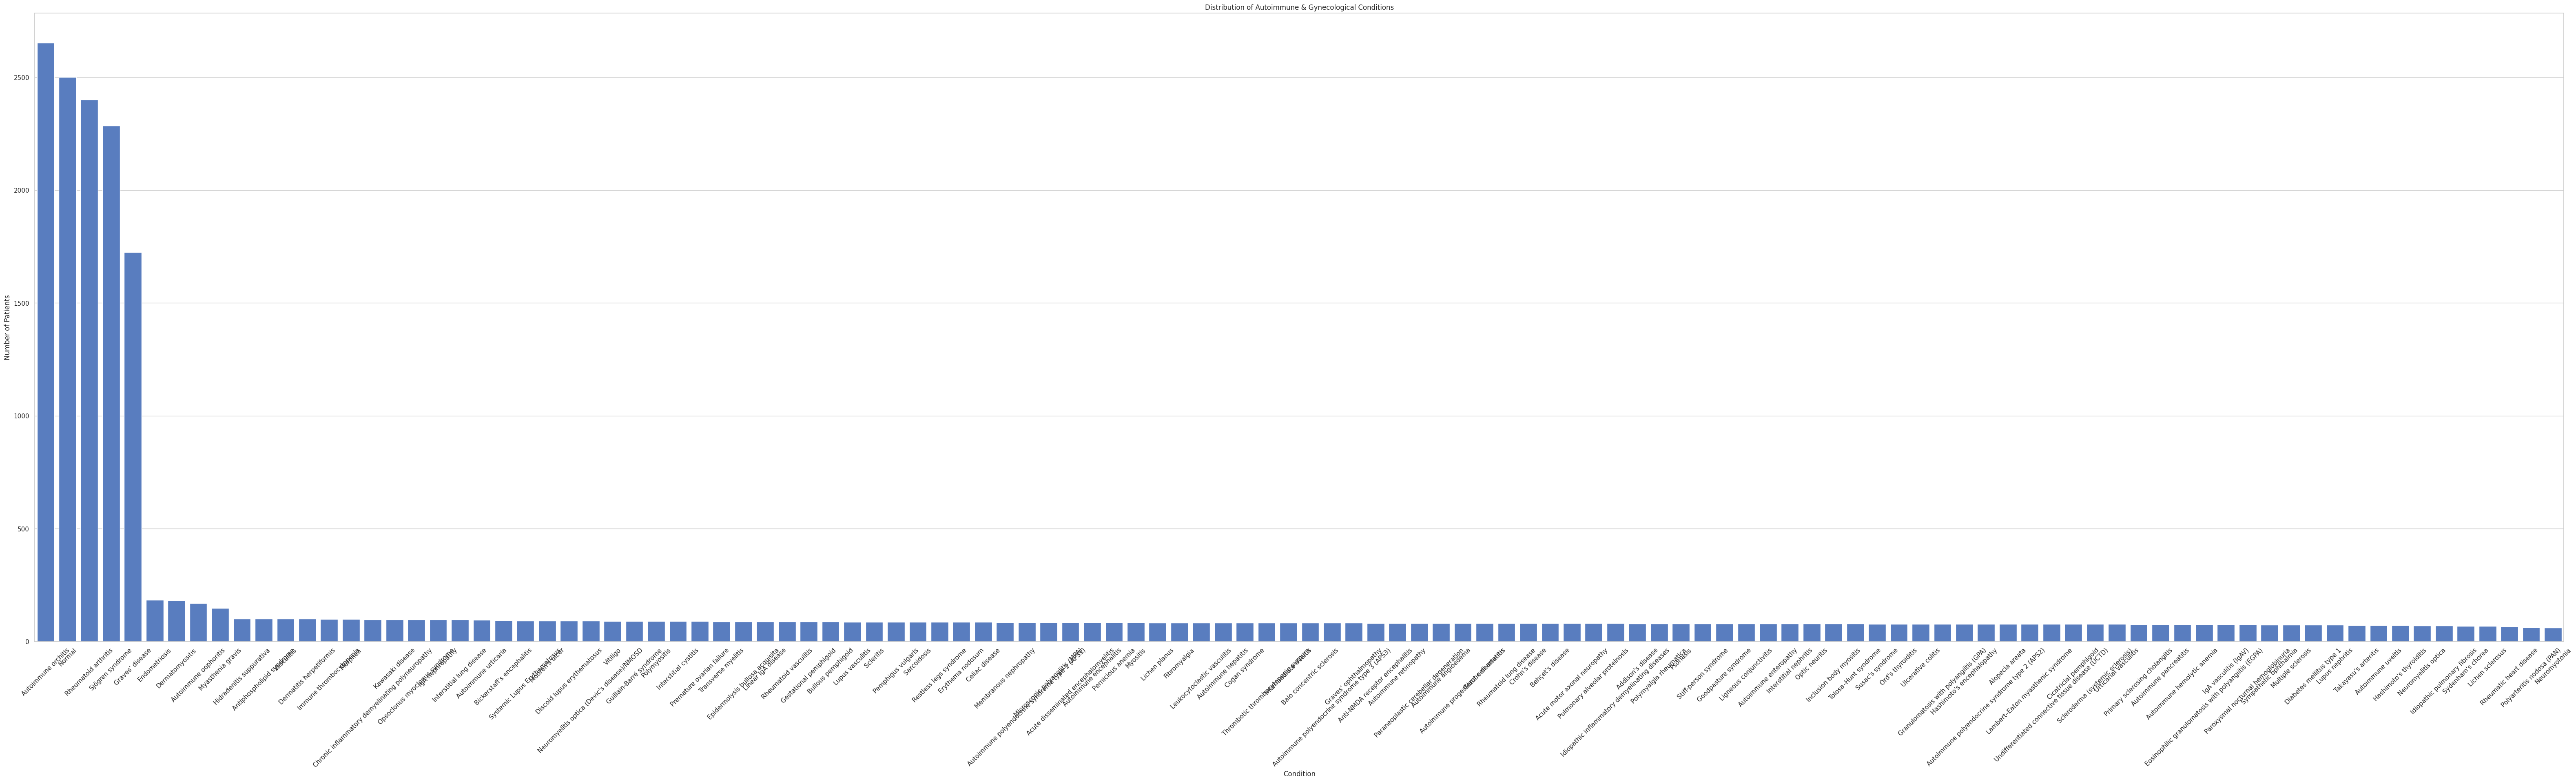

In [ ]:
plt.figure(figsize=(80, 20))
sns.countplot(data=df, x=target_col, order=df[target_col].value_counts().index)
plt.title('Distribution of Autoimmune & Gynecological Conditions')
plt.xlabel('Condition')
plt.ylabel('Number of Patients')
plt.xticks(rotation=45)
plt.show()

# Univariate Analysis (Examining Clinical Features)

histograms for first 6 numerical features to check for outliers


riham

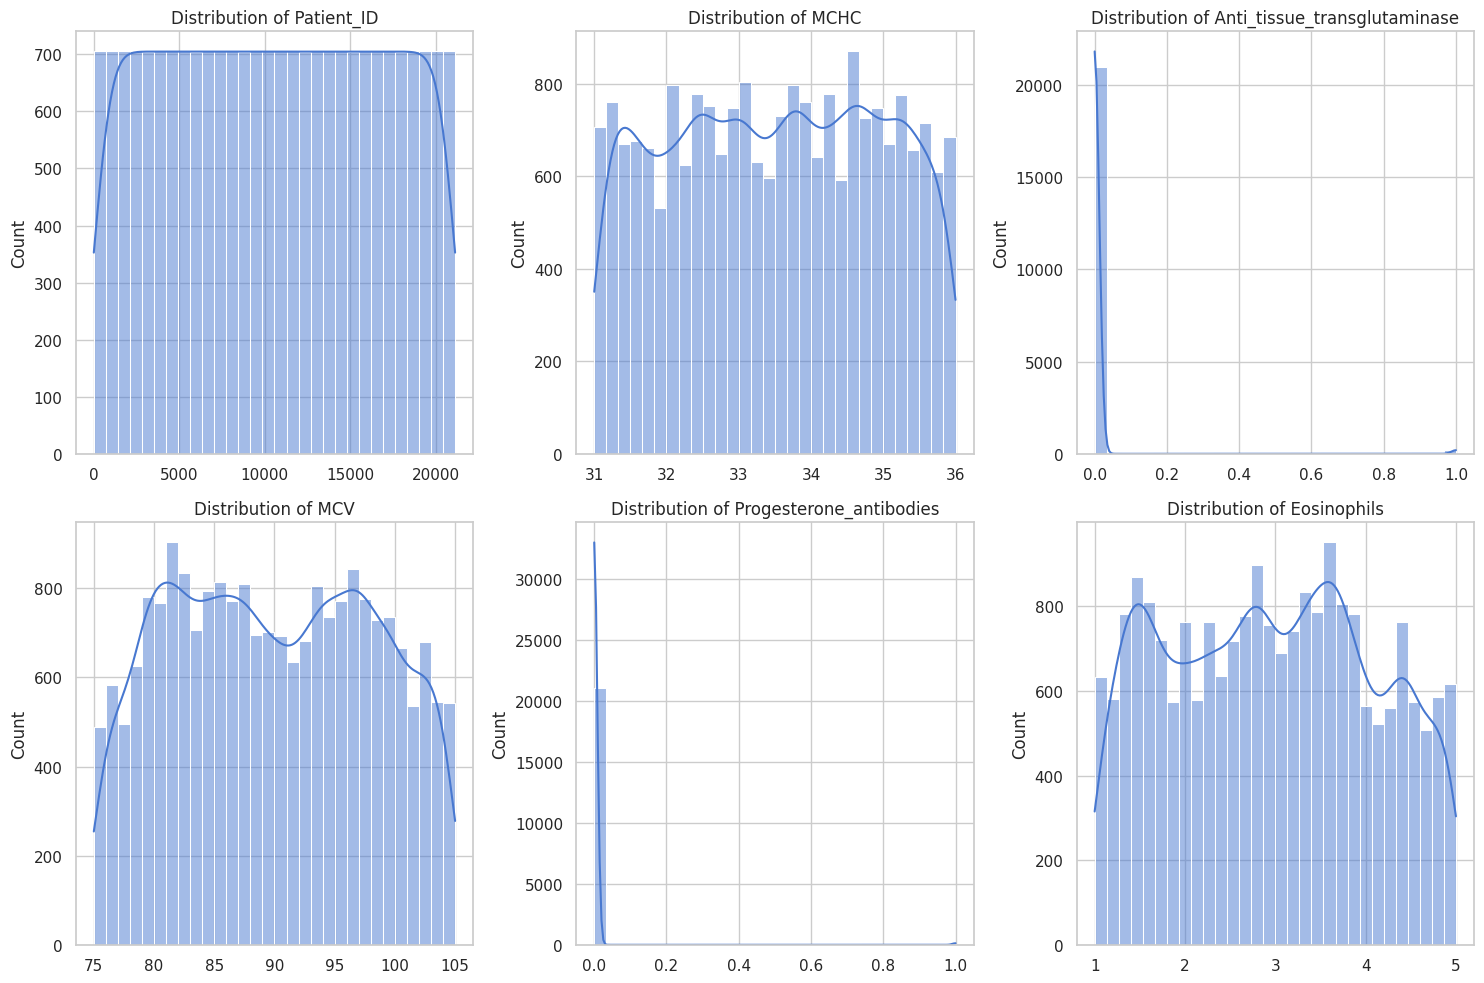

In [ ]:
num_cols = df.select_dtypes(include=['float64', 'int64']).columns

plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols[:6], 1):
    plt.subplot(2, 3, i)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.xlabel('')

plt.tight_layout()
plt.show()

# Quick histograms for all numerical columns at once

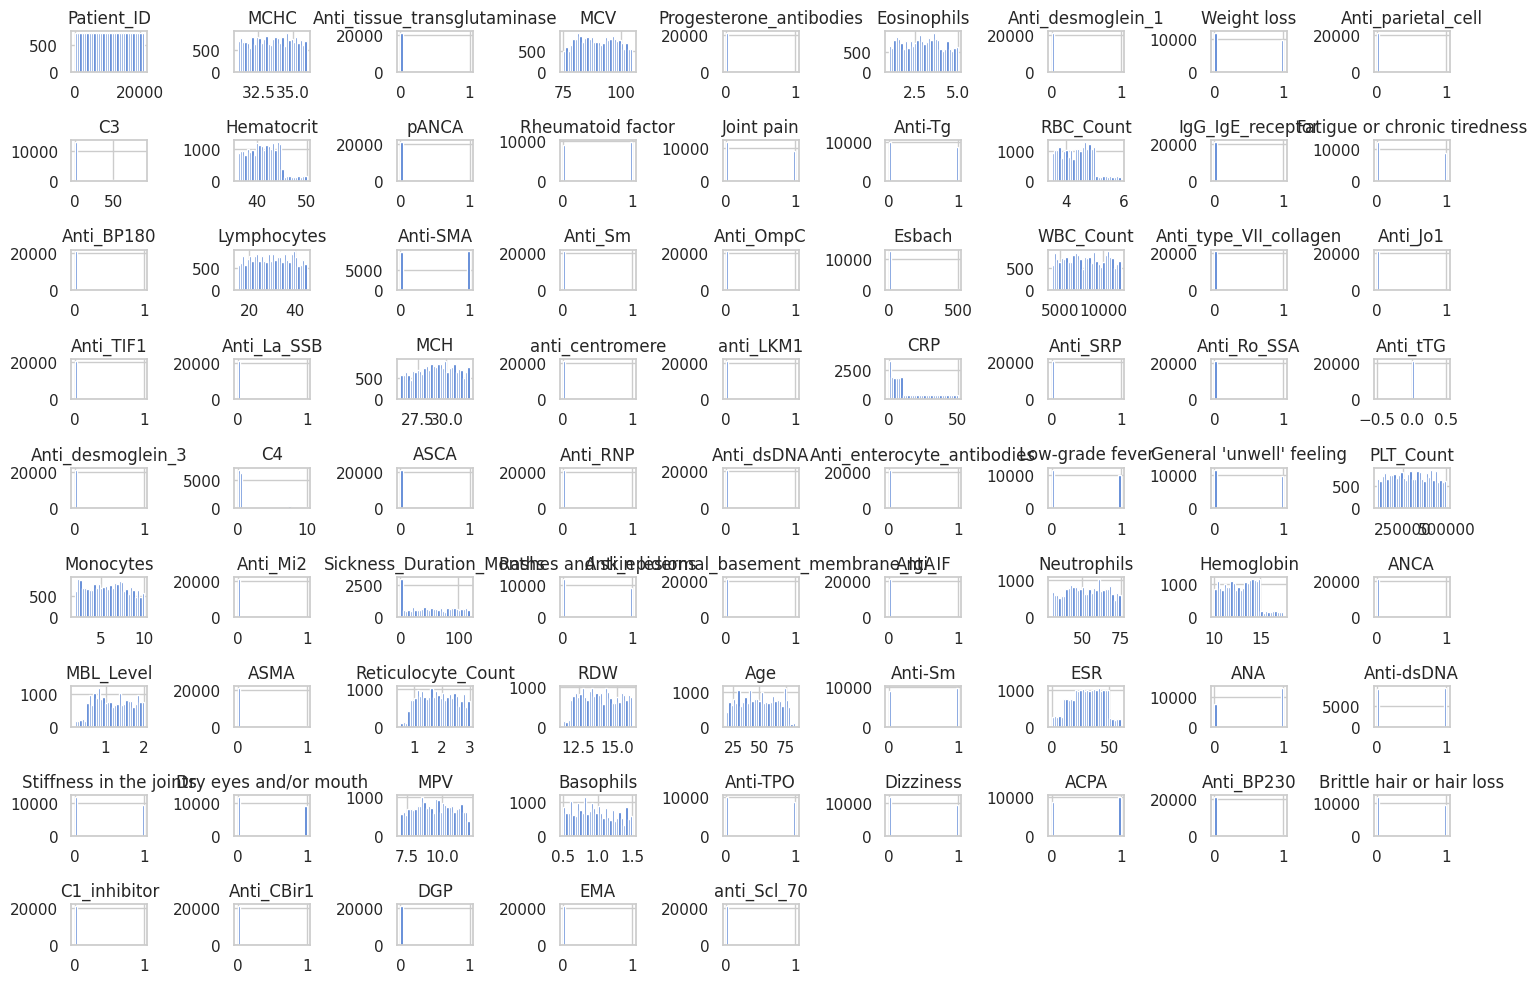

In [ ]:
df[num_cols].hist(figsize=(15, 10), bins=30)
plt.tight_layout()
plt.show()



youssef

# Bivariate Analysis (Features vs. Diseases)

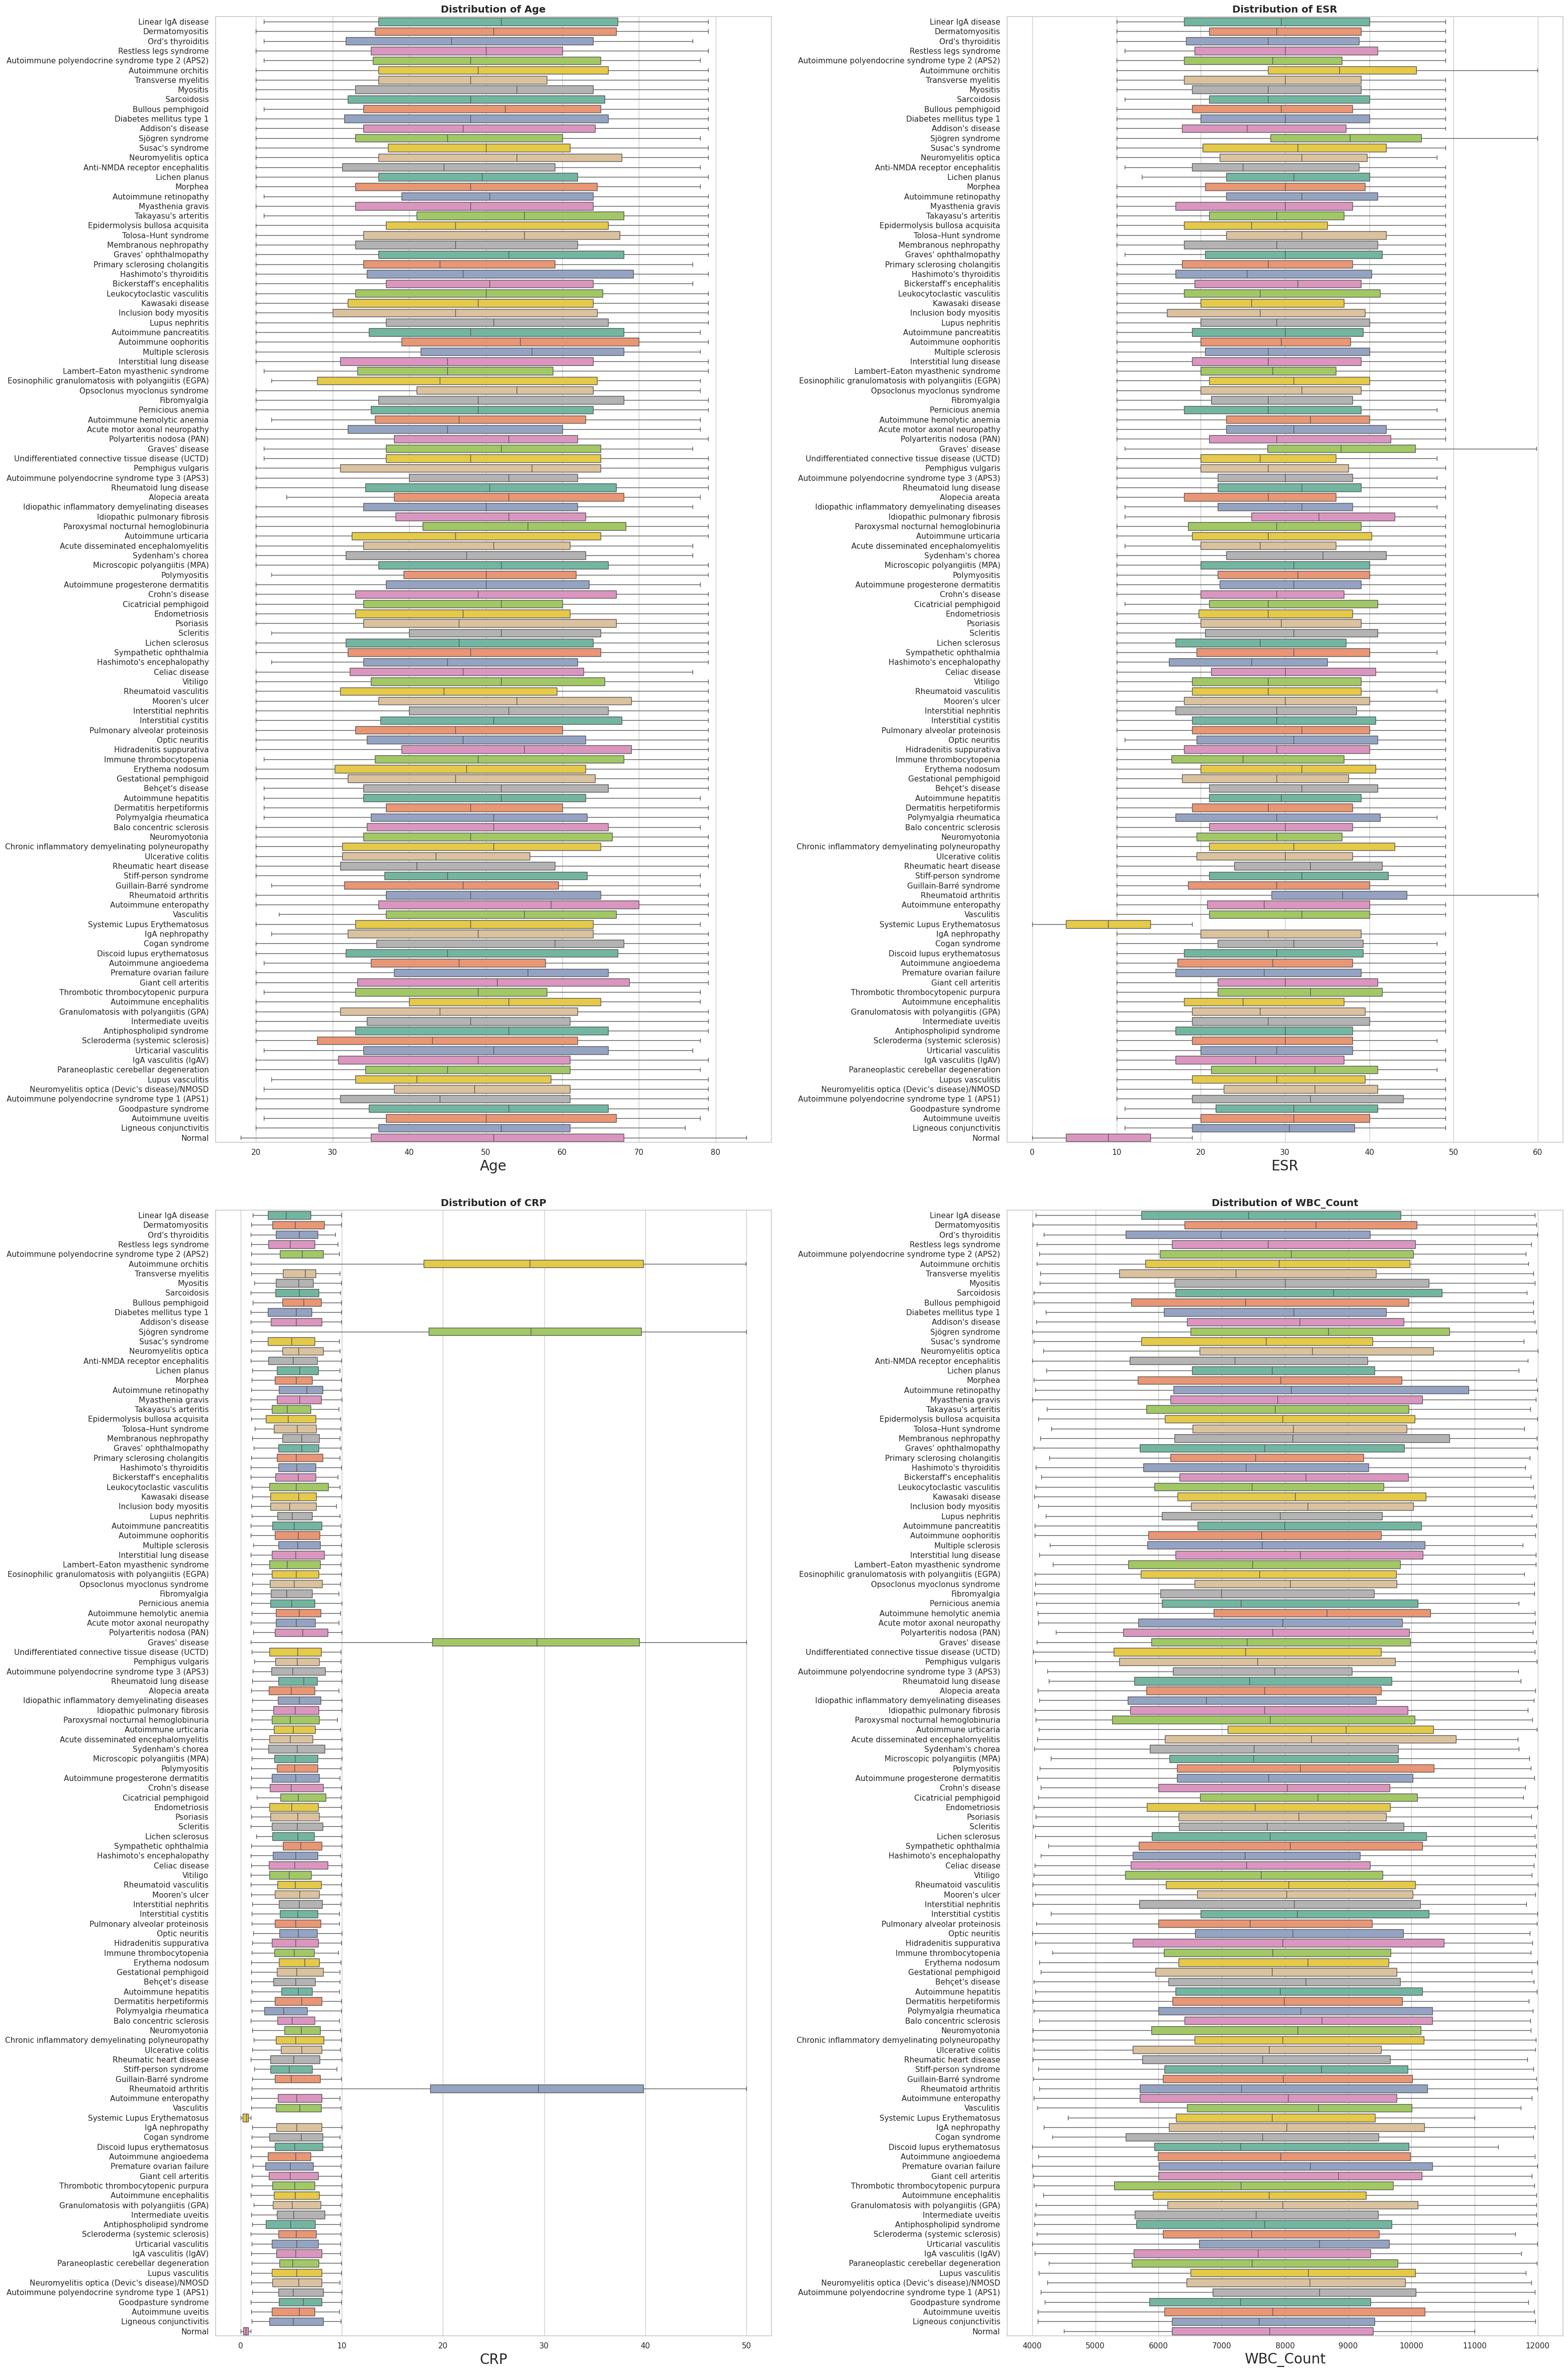

In [ ]:
features_to_compare = ['Age', 'ESR', 'CRP', 'WBC_Count']
plt.figure(figsize=(32, 48))
for i, col in enumerate(features_to_compare, 1):
    plt.subplot(2, 2, i)

    sns.boxplot(data=df, y=target_col, x=col, hue=target_col, palette="Set2", legend=False)

    plt.title(f'Distribution of {col}', fontsize=14, fontweight='bold')
    plt.ylabel('')
    plt.xlabel(col, fontsize=20)

plt.tight_layout(pad=3.0)
plt.show()

Bivariate Analysis (Features vs. TOP 5 Diseases)


raneem

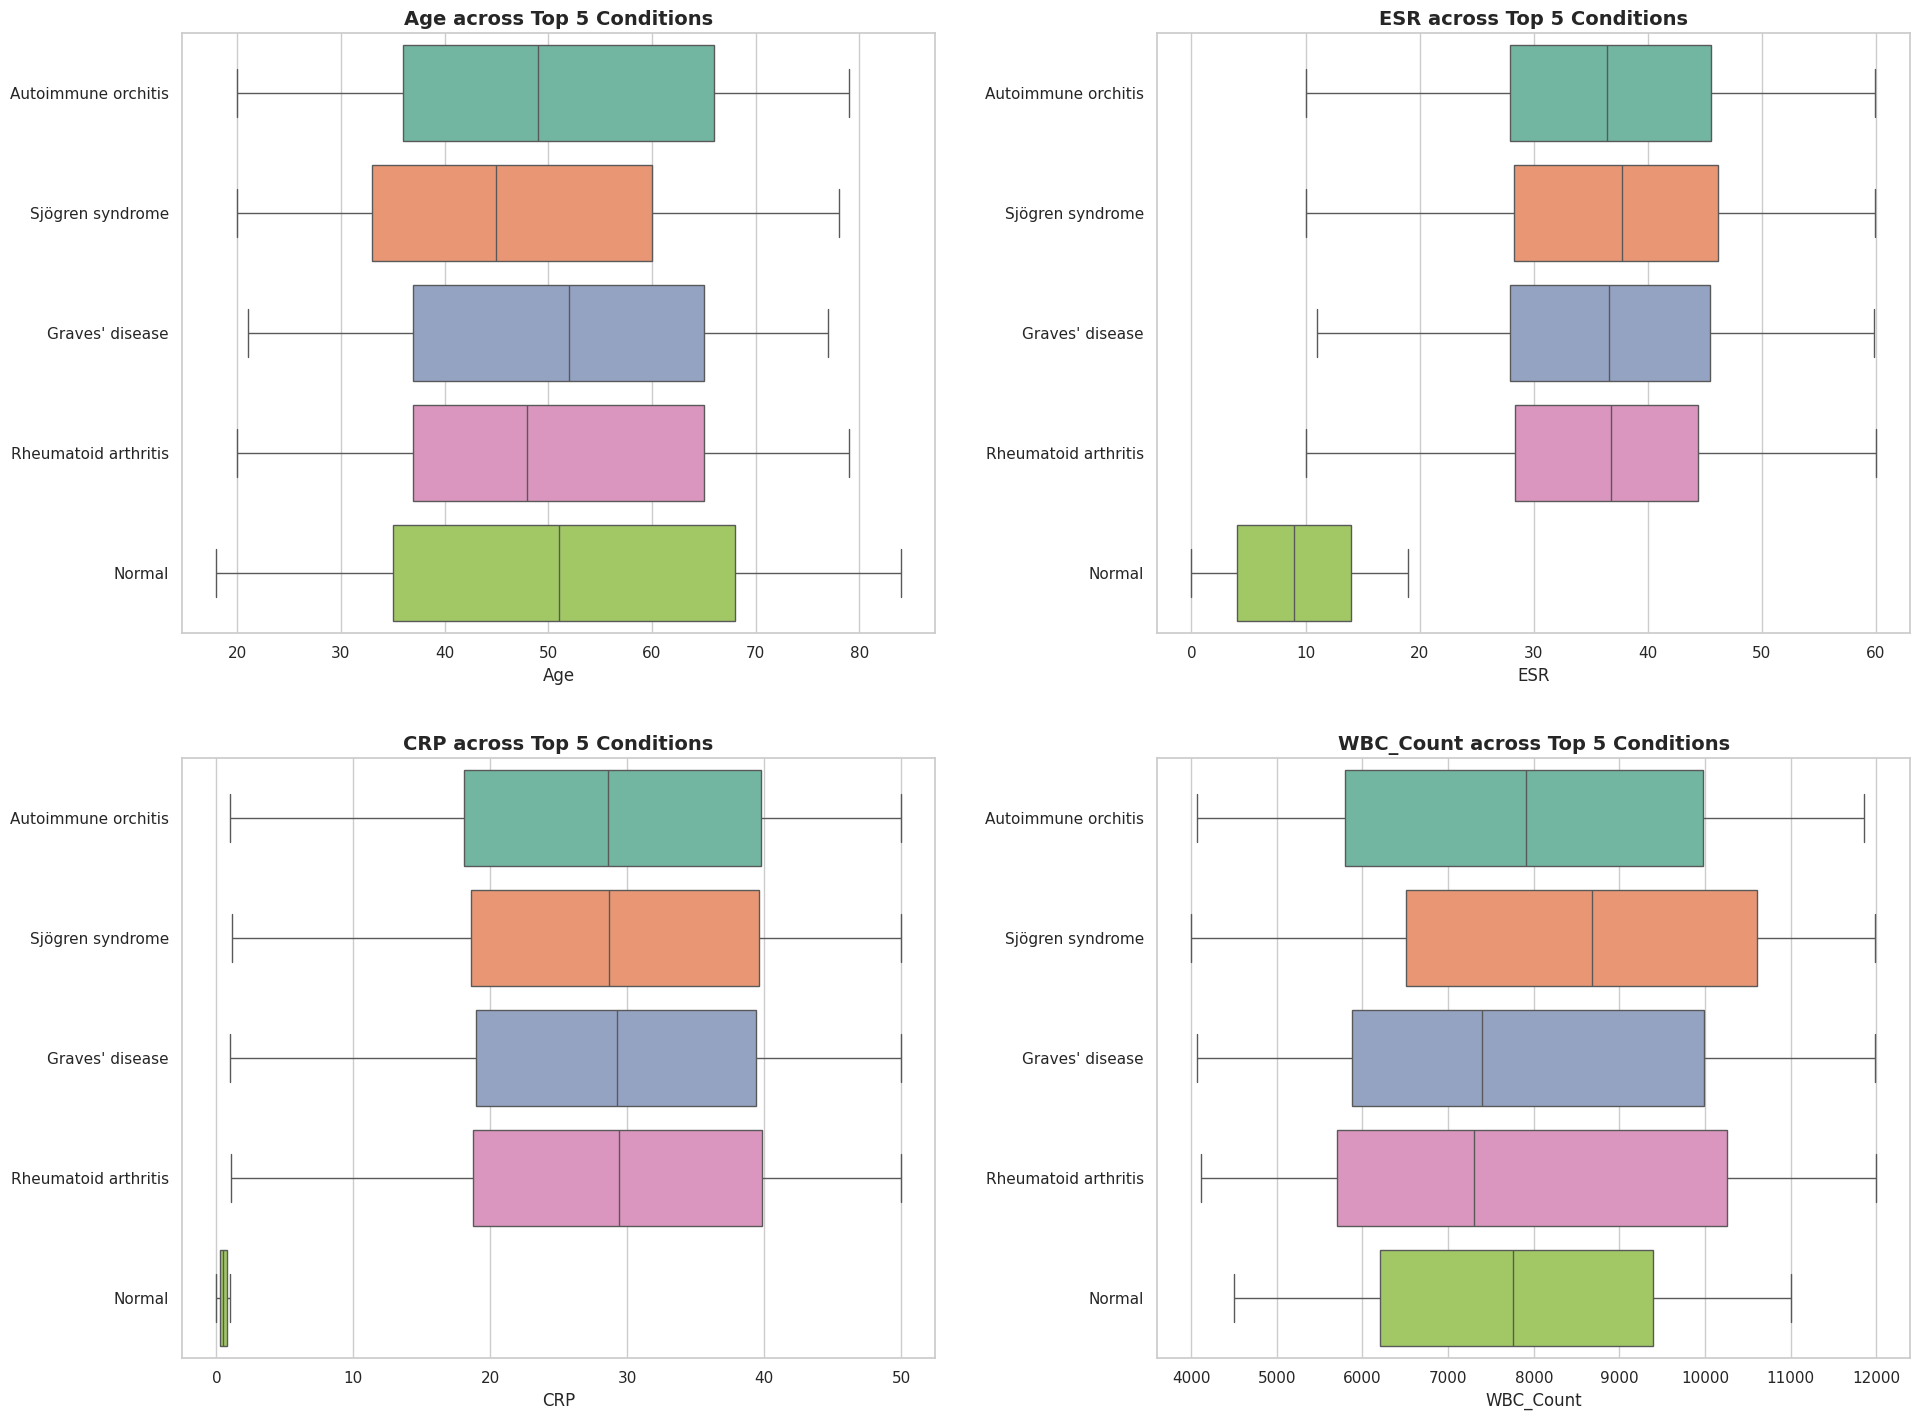

In [ ]:
target_col = 'Diagnosis'
features_to_compare = ['Age', 'ESR', 'CRP', 'WBC_Count']

top_5_diseases = df[target_col].value_counts().index[:5]
df_top5 = df[df[target_col].isin(top_5_diseases)]

plt.figure(figsize=(20, 15))
for i, col in enumerate(features_to_compare, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(data=df_top5, y=target_col, x=col, hue=target_col, palette="Set2", legend=False)
    plt.title(f'{col} across Top 5 Conditions', fontsize=14, fontweight='bold')
    plt.ylabel('')
    plt.xlabel(col, fontsize=12)

plt.tight_layout(pad=3.0)
plt.show()

raneem

# Multivariate Analysis (Correlation & Multicollinearity)

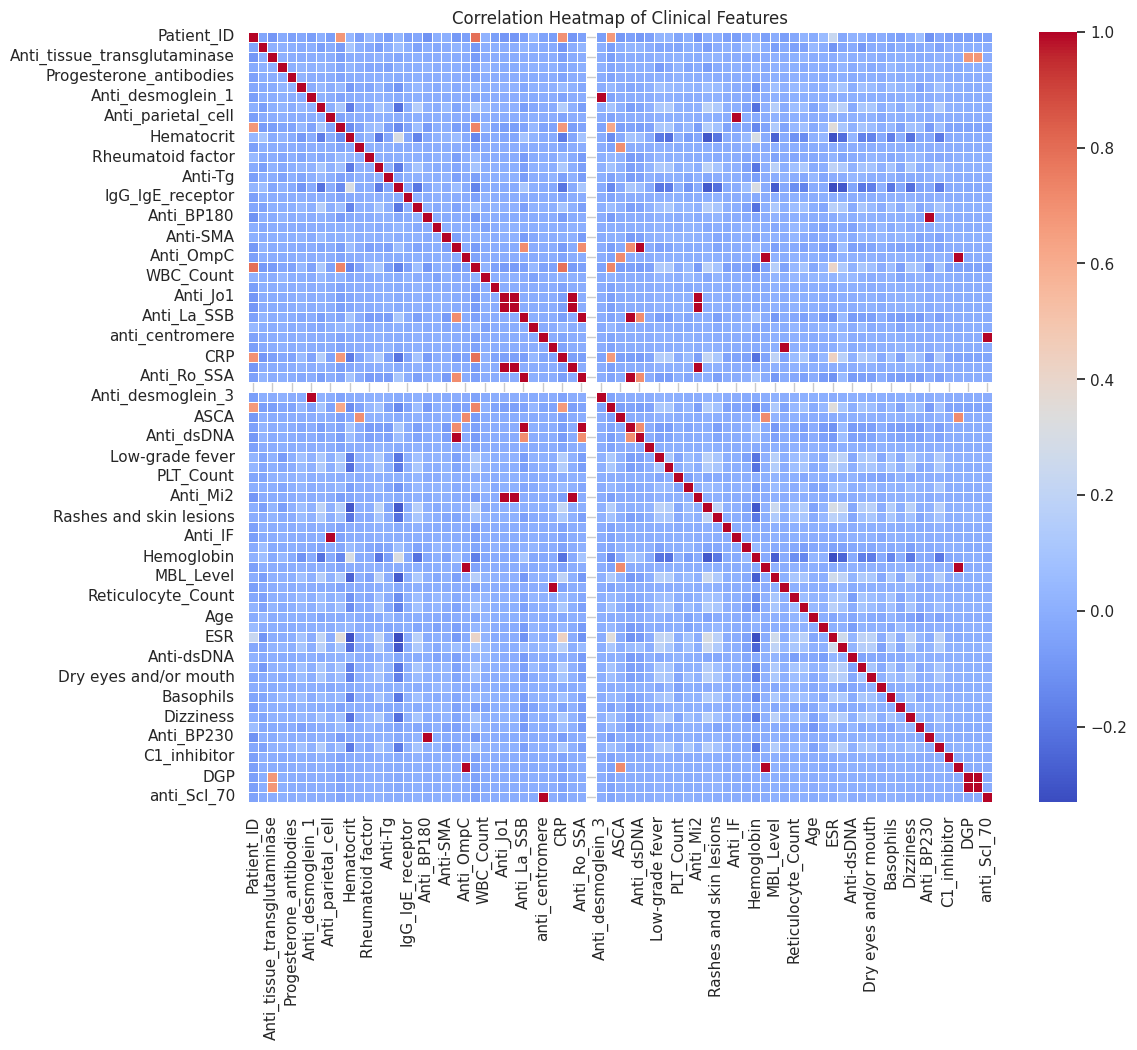

HIGHLY CORRELATED FEATURES (> 0.8)
Consider dropping these columns: ['Anti_TIF1', 'Anti_SRP', 'Anti_Ro_SSA', 'Anti_desmoglein_3', 'Anti_RNP', 'Anti_dsDNA', 'Anti_Mi2', 'Anti_IF', 'ANCA', 'ASMA', 'Anti_BP230', 'Anti_CBir1', 'EMA', 'anti_Scl_70']


In [ ]:
plt.figure(figsize=(12, 10))

# بCalculate the correlation matrix for numerical features
corr_matrix = df[num_cols].corr()

#elheatmap
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of Clinical Features')
plt.show()

# highly correlated pairs (threshold > 0.8)
print("HIGHLY CORRELATED FEATURES (> 0.8)")
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr = [column for column in upper_tri.columns if any(upper_tri[column] > 0.8)]
print(f"Consider dropping these columns: {high_corr}")

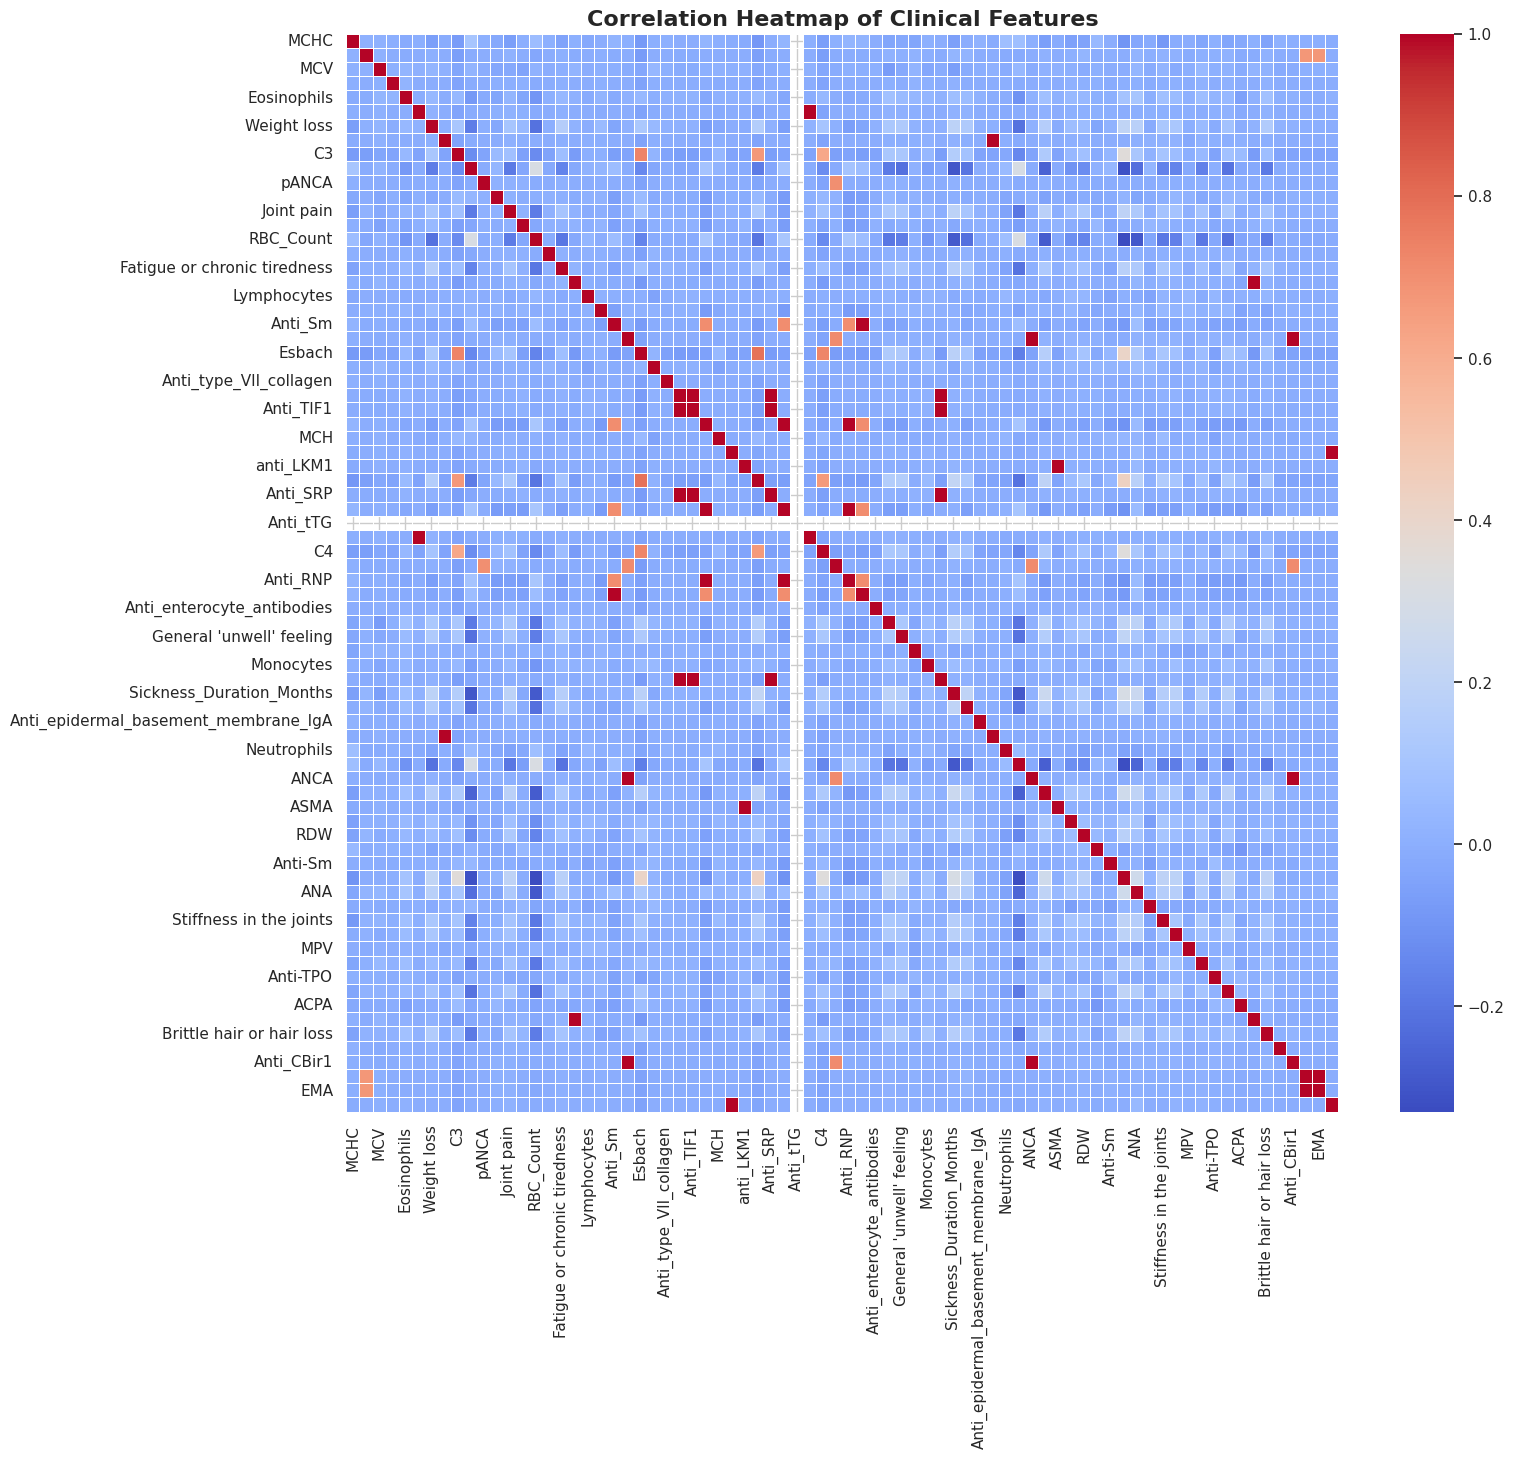

In [ ]:
# numerical columns and remove'Patient_ID' as it has no clinical value
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
num_cols = num_cols.drop('Patient_ID', errors='ignore')

plt.figure(figsize=(16, 14))
corr_matrix = df[num_cols].corr()

# the_heatmap
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of Clinical Features', fontsize=16, fontweight='bold')
plt.show()


In [ ]:
#highly correlated features (threshold > 0.8)
print("HIGHLY CORRELATED FEATURES (> 0.8)")
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr = [column for column in upper_tri.columns if any(upper_tri[column] > 0.8)]
print(f"Consider dropping these columns: {high_corr}")

HIGHLY CORRELATED FEATURES (> 0.8)
Consider dropping these columns: ['Anti_TIF1', 'Anti_SRP', 'Anti_Ro_SSA', 'Anti_desmoglein_3', 'Anti_RNP', 'Anti_dsDNA', 'Anti_Mi2', 'Anti_IF', 'ANCA', 'ASMA', 'Anti_BP230', 'Anti_CBir1', 'EMA', 'anti_Scl_70']


# Categorical Analysis (Gender)


ahmed

/tmp/ipykernel_4335/3936932106.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Gender', palette='pastel')


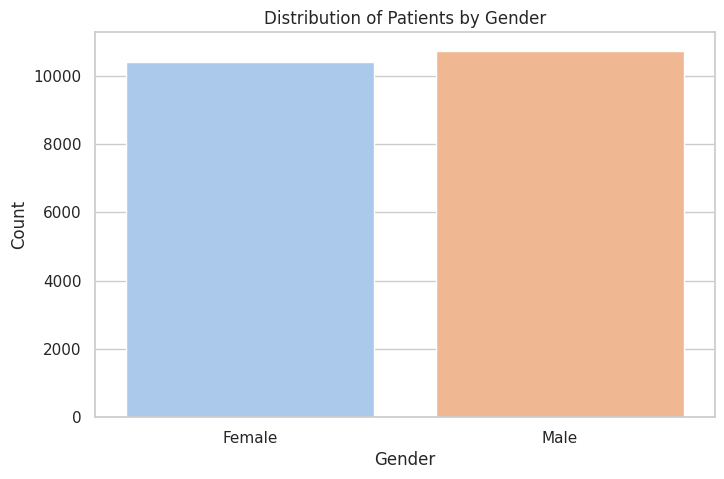

In [ ]:
if 'Gender' in df.columns:
    plt.figure(figsize=(8, 5))
    sns.countplot(data=df, x='Gender', palette='pastel')
    plt.title('Distribution of Patients by Gender')
    plt.xlabel('Gender')
    plt.ylabel('Count')
    plt.show()